<a href="https://colab.research.google.com/github/Nishank9126/IIT-Indore/blob/main/MSLP_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

# Define the paths for your downloaded dataset
# CHANGE THESE PATHS if your dataset is located elsewhere in your Google Drive
DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
XML_DIR = os.path.join(DATASET_ROOT, "annotations")

# Define where the output masks and JSON will be saved
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

# Create the output directory for the PNG masks
os.makedirs(OUTPUT_MASKS_DIR, exist_ok=True)
print(f"Directories configured. Masks will be saved to: {OUTPUT_MASKS_DIR}")

Directories configured. Masks will be saved to: /content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train/sam_masks


In [ ]:
import os
import cv2
import numpy as np
import json
import xml.etree.ElementTree as ET
from glob import glob
from tqdm import tqdm

# --- PATHS ---
DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
XML_DIR = os.path.join(DATASET_ROOT, "annotations", "xml_format")
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

os.makedirs(OUTPUT_MASKS_DIR, exist_ok=True)

def obb_to_mask(x_center, y_center, width, height, angle_radians, image_shape):
    """Converts OBB coordinates into a binary pixel mask."""
    angle_degrees = np.degrees(angle_radians)
    rect = ((x_center, y_center), (width, height), angle_degrees)
    box_points = cv2.boxPoints(rect)

    # --- FIX APPLIED HERE: Changed np.int0 to np.int32 ---
    box_points = np.int32(box_points)

    mask = np.zeros(image_shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [box_points], 255)
    return mask

coco_format = {
    "info": {"description": "OCD Dataset mapped for SAM 3 PCS Training - Dynamic Labels"},
    "images": [],
    "categories": [],
    "annotations": []
}

# Dynamic mapping variables
category_map = {}
category_id_counter = 1
annotation_id = 1
image_id = 1

# Gather all image files
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.tif', '*.tiff']:
    image_files.extend(glob(os.path.join(IMAGES_DIR, ext)))

print(f"Found {len(image_files)} images. Processing...")

for img_path in tqdm(image_files):
    filename = os.path.basename(img_path)
    base_name = os.path.splitext(filename)[0]

    xml_path = os.path.join(XML_DIR, f"{base_name}.xml")
    if not os.path.exists(xml_path):
        continue

    image = cv2.imread(img_path)
    if image is None:
        continue
    image_shape = image.shape

    coco_format["images"].append({
        "id": image_id,
        "file_name": filename,
        "width": image_shape[1],
        "height": image_shape[0]
    })

    tree = ET.parse(xml_path)
    root = tree.getroot()

    mask_counter = 0
    for obj in root.findall('object'):
        name_tag = obj.find('name')
        if name_tag is None:
            continue

        # Clean the class name
        class_name = str(name_tag.text).strip().lower()

        # DYNAMIC CATEGORY CREATION
        if class_name not in category_map:
            category_map[class_name] = category_id_counter

            # Format the prompt nicely
            prompt_text = class_name
            if prompt_text.endswith("cell") and prompt_text != "cell":
                prompt_text = prompt_text[:-4] + " cell"
            elif prompt_text == "hardtosee":
                prompt_text = "hard to see cell"
            elif prompt_text == "affectedbytreatment":
                prompt_text = "affected by treatment cell"
            elif not prompt_text.endswith("cell"):
                prompt_text = prompt_text + " cell"

            coco_format["categories"].append({
                "id": category_id_counter,
                "name": class_name,
                "prompt": prompt_text
            })
            category_id_counter += 1

        robndbox = obj.find('robndbox')
        if robndbox is None:
            continue

        # Extract coordinates
        cx = float(robndbox.find('cx').text)
        cy = float(robndbox.find('cy').text)
        w = float(robndbox.find('w').text)
        h = float(robndbox.find('h').text)
        angle = float(robndbox.find('angle').text)

        # Generate and save mask
        mask = obb_to_mask(cx, cy, w, h, angle, image_shape)
        mask_filename = f"{base_name}_mask_{mask_counter}.png"
        mask_filepath = os.path.join(OUTPUT_MASKS_DIR, mask_filename)
        cv2.imwrite(mask_filepath, mask)

        # Map to COCO JSON
        current_prompt = next(cat["prompt"] for cat in coco_format["categories"] if cat["id"] == category_map[class_name])

        coco_format["annotations"].append({
            "id": annotation_id,
            "image_id": image_id,
            "category_id": category_map[class_name],
            "mask_file": mask_filename,
            "text_prompt": current_prompt
        })

        annotation_id += 1
        mask_counter += 1

    image_id += 1

# Save the final JSON
with open(OUTPUT_JSON_PATH, 'w') as json_file:
    json.dump(coco_format, json_file, indent=4)

print(f"\n--- EXTRACTION COMPLETE ---")
print(f"Total masks generated successfully: {annotation_id - 1}")
print(f"JSON mapping saved to: {OUTPUT_JSON_PATH}")
print("\nDynamically mapped categories and prompts for SAM 3:")
for cat in coco_format["categories"]:
    print(f" - Raw XML label: '{cat['name']}' -> SAM 3 Prompt: '{cat['prompt']}'")

Found 96 images. Processing...


100%|██████████| 96/96 [02:35<00:00,  1.62s/it]


--- EXTRACTION COMPLETE ---
Total masks generated successfully: 4531
JSON mapping saved to: /content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train/sam_coco_annotations.json

Dynamically mapped categories and prompts for SAM 3:
 - Raw XML label: 'cell' -> SAM 3 Prompt: 'cell'
 - Raw XML label: 'normalcell' -> SAM 3 Prompt: 'normal cell'
 - Raw XML label: 'roundcell' -> SAM 3 Prompt: 'round cell'
 - Raw XML label: 'affectedbytreatment' -> SAM 3 Prompt: 'affected by treatment cell'
 - Raw XML label: 'hardtosee' -> SAM 3 Prompt: 'hard to see cell'
 - Raw XML label: 'analyzelater' -> SAM 3 Prompt: 'analyzelater cell'


--- VERIFICATION RESULTS ---
✅ Found 4531 PNG masks successfully saved in your Drive.
✅ JSON file created! It successfully mapped 4531 cell instances.

Dynamic Categories Created for SAM 3:
 - cell
 - normal cell
 - round cell
 - affected by treatment cell
 - hard to see cell
 - analyzelater cell


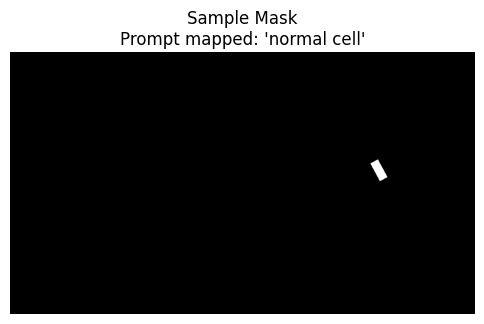

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import cv2
import random

DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

print("--- VERIFICATION RESULTS ---")

# 1. Check the Masks Folder
if os.path.exists(OUTPUT_MASKS_DIR):
    masks_found = [f for f in os.listdir(OUTPUT_MASKS_DIR) if f.endswith('.png')]
    print(f" Found {len(masks_found)} PNG masks successfully saved in your Drive.")
else:
    print(" Mask folder not found.")

# 2. Check the JSON Mapping File
if os.path.exists(OUTPUT_JSON_PATH):
    with open(OUTPUT_JSON_PATH, 'r') as f:
        coco_data = json.load(f)
    print(f" JSON file created! It successfully mapped {len(coco_data['annotations'])} cell instances.")

    print("\nDynamic Categories Created for SAM 3:")
    for cat in coco_data['categories']:
        print(f" - {cat['prompt']}")

    # 3. Visualize a random mask
    if len(coco_data['annotations']) > 0:
        sample = random.choice(coco_data['annotations'])
        mask_path = os.path.join(OUTPUT_MASKS_DIR, sample['mask_file'])

        mask_img = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        plt.figure(figsize=(6, 6))
        plt.imshow(mask_img, cmap='gray')
        plt.title(f"Sample Mask\nPrompt mapped: '{sample['text_prompt']}'")
        plt.axis('off')
        plt.show()
else:
    print("❌ JSON file not found.")

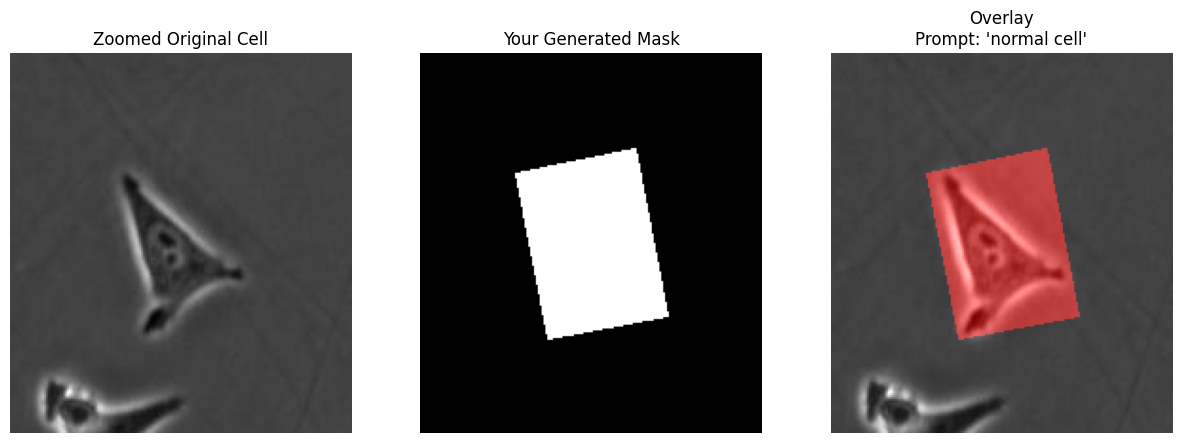

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import cv2
import random
import numpy as np

DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

# Load JSON
with open(OUTPUT_JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# Pick a random annotation
sample = random.choice(coco_data['annotations'])
img_info = next(item for item in coco_data["images"] if item["id"] == sample["image_id"])

# Load Images
orig_img = cv2.imread(os.path.join(IMAGES_DIR, img_info["file_name"]))
orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
mask_img = cv2.imread(os.path.join(OUTPUT_MASKS_DIR, sample['mask_file']), cv2.IMREAD_GRAYSCALE)

# Find where the cell is so we can zoom in on it
y_indices, x_indices = np.where(mask_img == 255)
if len(x_indices) > 0 and len(y_indices) > 0:
    x_min, x_max = max(0, min(x_indices) - 50), min(orig_img.shape[1], max(x_indices) + 50)
    y_min, y_max = max(0, min(y_indices) - 50), min(orig_img.shape[0], max(y_indices) + 50)

    # Crop to zoom
    zoomed_img = orig_img[y_min:y_max, x_min:x_max]
    zoomed_mask = mask_img[y_min:y_max, x_min:x_max]

    # Create an overlay (Color the mask Red and blend it)
    colored_mask = np.zeros_like(zoomed_img)
    colored_mask[zoomed_mask == 255] = [255, 0, 0] # Red
    overlay = cv2.addWeighted(zoomed_img, 1.0, colored_mask, 0.5, 0)

    # Plot
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(zoomed_img)
    axes[0].set_title("Zoomed Original Cell")
    axes[1].imshow(zoomed_mask, cmap='gray')
    axes[1].set_title("Your Generated Mask")
    axes[2].imshow(overlay)
    axes[2].set_title(f"Overlay\nPrompt: '{sample['text_prompt']}'")

    for ax in axes:
        ax.axis('off')
    plt.show()

In [ ]:
import os
from glob import glob

DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"

print("--- DIRECTORY CONTENTS ---")
print(f"Items inside {DATASET_ROOT}:")
for item in os.listdir(DATASET_ROOT):
    item_path = os.path.join(DATASET_ROOT, item)
    if os.path.isdir(item_path):
        print(f"  [FOLDER] {item}")
        # Show a few files inside this folder
        files = os.listdir(item_path)
        print(f"    Contains {len(files)} files. First 3: {files[:3]}")
    else:
        print(f"  [FILE] {item}")

# Let's find out what extension your annotations actually use
all_files = glob(os.path.join(DATASET_ROOT, "**/*.*"), recursive=True)
extensions = set([os.path.splitext(f)[1].lower() for f in all_files])
print(f"\nAll file types found in this split: {extensions}")

--- DIRECTORY CONTENTS ---
Items inside /content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train:
 📁 [FOLDER] annotations
    Contains 2 files. First 3: ['alpr_format', 'xml_format']
 📁 [FOLDER] .ipynb_checkpoints
    Contains 0 files. First 3: []
 📁 [FOLDER] images
    Contains 96 files. First 3: ['exp_M2_Mauricio_mcr5_frame_29.png', 'exp_M1_Mauricio_mcf7_frame_16.png', 'exp_LJ8_LuanaeJulieti_U251_nan_CT_1min_T1552480068.jpg']
 📁 [FOLDER] sam_masks
    Contains 4531 files. First 3: ['exp_LJ12.2_LuanaeJulieti_A172_F9DP53_TMZ3horas(conferir)_50uM_2min_T1557977179_mask_17.png', 'exp_LJ12.2_LuanaeJulieti_A172_F9DP53_TMZ3horas(conferir)_50uM_2min_T1557977179_mask_18.png', 'exp_LJ12.2_LuanaeJulieti_A172_F9DP53_TMZ3horas(conferir)_50uM_2min_T1557977179_mask_19.png']
 📄 [FILE] sam_coco_annotations.json

All file types found in this split: {'.xml', '.json', '.txt', '.jpg', '.png'}


In [ ]:
import os
import shutil
from google.colab import files

# Your existing paths
DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

# Name of the zip file we will create
ZIP_FILENAME = "sam3_ocd_dataset"
ZIP_FILEPATH = f"/content/{ZIP_FILENAME}.zip"
TEMP_BUNDLE_DIR = f"/content/{ZIP_FILENAME}"

print("Step 1: Bundling files together...")
# Create a temporary folder to hold both the masks and the JSON
os.makedirs(TEMP_BUNDLE_DIR, exist_ok=True)

# Copy the masks folder and the JSON file into the bundle folder
shutil.copytree(OUTPUT_MASKS_DIR, os.path.join(TEMP_BUNDLE_DIR, "sam_masks"), dirs_exist_ok=True)
shutil.copy2(OUTPUT_JSON_PATH, TEMP_BUNDLE_DIR)

print("Step 2: Zipping 4,500+ files. This might take a minute or two...")
# Compress the folder into a zip file
shutil.make_archive(f"/content/{ZIP_FILENAME}", 'zip', TEMP_BUNDLE_DIR)

print("Step 3: Triggering download to your computer!")
# Prompt the browser to download the zip file to your local hard drive
files.download(ZIP_FILEPATH)

print("Note: Depending on your browser, it may take a few moments for the 'Save As' window to appear.")

Step 1: Bundling files together...
Step 2: Zipping 4,500+ files. This might take a minute or two...
Step 3: Triggering download to your computer!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Note: Depending on your browser, it may take a few moments for the 'Save As' window to appear.


In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git
!pip install -q datasets accelerate pycocotools opencv-python matplotlib

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from huggingface_hub import notebook_login
print("Please paste your Hugging Face Access Token to download SAM:")
notebook_login()

Please paste your Hugging Face Access Token to download SAM:


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
import json
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import AutoProcessor, AutoModelForMaskGeneration

DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")
OUTPUT_MASKS_DIR = os.path.join(DATASET_ROOT, "sam_masks")
OUTPUT_JSON_PATH = os.path.join(DATASET_ROOT, "sam_coco_annotations.json")

class OrientedCellDataset(Dataset):
    def __init__(self, json_path, images_dir, masks_dir, processor):
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.processor = processor
        with open(json_path, 'r') as f:
            self.coco_data = json.load(f)
        self.annotations = self.coco_data['annotations']
        self.image_lookup = {img['id']: img for img in self.coco_data['images']}

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]
        img_info = self.image_lookup[ann['image_id']]

        img_path = os.path.join(self.images_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        mask_path = os.path.join(self.masks_dir, ann['mask_file'])
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.uint8)

        text_prompt = ann['text_prompt']

        inputs = self.processor(
            images=image,
            segmentation_maps=mask,
            text=text_prompt,
            return_tensors="pt"
        )

        inputs = {k: v.squeeze(0) for k, v in inputs.items()}
        inputs['raw_text'] = text_prompt
        return inputs
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_ID = "facebook/sam-vit-base"

print("Loading Processor and Model...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForMaskGeneration.from_pretrained(MODEL_ID).to(device)

train_dataset = OrientedCellDataset(
    json_path=OUTPUT_JSON_PATH,
    images_dir=IMAGES_DIR,
    masks_dir=OUTPUT_MASKS_DIR,
    processor=processor
)

Loading Processor and Model...


The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

In [ ]:
print(f"Dataset ready! Total training instances: {len(train_dataset)}")

Dataset ready! Total training instances: 4531


In [ ]:
code_to_run = """import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

def dice_loss(inputs, targets, smooth=1e-5):
@inputs = torch.sigmoid(inputs)
@inputs = inputs.view(-1)
@targets = targets.view(-1)
@intersection = (inputs * targets).sum()
@dice = (2. * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
@return 1 - dice

BATCH_SIZE = 6
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

for name, param in model.named_parameters():
@if "vision_encoder" in name:
@@param.requires_grad = False
@else:
@@param.requires_grad = True

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=0.01)

EPOCHS = 2
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Starting Training on {device.upper()}...")
model.train()

for epoch in range(EPOCHS):
@epoch_loss = 0.0
@progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{EPOCHS}")
@
@for batch in progress_bar:
@@inputs = {k: v.to(device) for k, v in batch.items() if k not in ['raw_text', 'labels']}
@@
@@if 'labels' in batch:
@@@ground_truth_masks = batch['labels'].to(device)
@@else:
@@@raise ValueError("Could not find ground truth masks ('labels') in the batch!")
@@
@@optimizer.zero_grad()
@@outputs = model(**inputs)
@@
@@predicted_mask_logits = outputs.pred_masks[:, :, 0, :, :]
@@
@@if ground_truth_masks.dim() == 3:
@@@ground_truth_masks = ground_truth_masks.unsqueeze(1)
@@ground_truth_masks = ground_truth_masks.float()
@@
@@if predicted_mask_logits.shape[-2:] != ground_truth_masks.shape[-2:]:
@@@ground_truth_masks = F.interpolate(ground_truth_masks, size=predicted_mask_logits.shape[-2:], mode="nearest")
@@
@@bce_l = F.binary_cross_entropy_with_logits(predicted_mask_logits, ground_truth_masks)
@@dice_l = dice_loss(predicted_mask_logits, ground_truth_masks)
@@
@@loss = bce_l + dice_l
@@loss.backward()
@@optimizer.step()
@@
@@epoch_loss += loss.item()
@@progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})
@@
@avg_loss = epoch_loss / len(train_dataloader)
@print(f"Epoch {epoch+1} Completed | Average Loss: {avg_loss:.4f}")

FINE_TUNED_DIR = "/content/drive/MyDrive/MSLP_dataset/cell_detector/sam3_finetuned"
model.save_pretrained(FINE_TUNED_DIR)
processor.save_pretrained(FINE_TUNED_DIR)
print(f"Fine-tuned model safely saved to: {FINE_TUNED_DIR}")
"""

# This automatically fixes the missing spaces caused by the UI bug and runs the code!
perfect_code = code_to_run.replace("@", "    ")
exec(perfect_code)

Starting Training on CUDA...


Epoch 1/2: 100%|██████████| 756/756 [39:39<00:00,  3.15s/it, loss=0.9750]


Epoch 1 Completed | Average Loss: 0.9987


Epoch 2/2: 100%|██████████| 756/756 [39:34<00:00,  3.14s/it, loss=1.0012]

Epoch 2 Completed | Average Loss: 0.9700


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuned model safely saved to: /content/drive/MyDrive/MSLP_dataset/cell_detector/sam3_finetuned


Detecting 'normal cell' instances in the image...
------------------------------
BIOLOGICAL METRICS EXTRACTED:
Cells Detected: 44
Total Cell Confluence: 3.36%
Average Cell Polarity: 2.10
Dynamic Threshold Used: 0.85 (Max Confidence: 2.85)
------------------------------


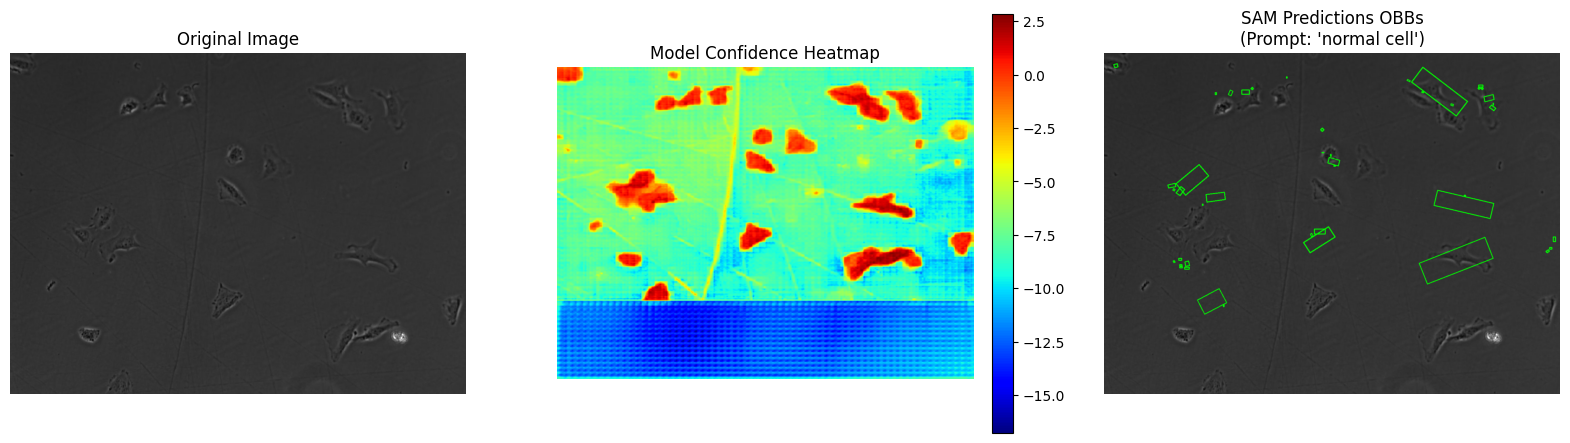

In [ ]:
code_for_step_4 = """import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import random

DATASET_ROOT = "/content/drive/MyDrive/MSLP_dataset/cell_detector/annotations_split/train"
IMAGES_DIR = os.path.join(DATASET_ROOT, "images")

def extract_all_metrics(predicted_mask_2d, total_image_area):
@mask_np = predicted_mask_2d.cpu().numpy().astype(np.uint8) * 255
@contours, _ = cv2.findContours(mask_np, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
@
@results = []
@for cnt in contours:
@@if cv2.contourArea(cnt) < 5:
@@@continue
@@rect = cv2.minAreaRect(cnt)
@@(x_c, y_c), (w, h), angle = rect
@@major_axis = max(w, h)
@@minor_axis = min(w, h)
@@if minor_axis == 0:
@@@continue
@@polarity = major_axis / minor_axis
@@obb_area = w * h
@@confluence_contrib = obb_area / total_image_area
@@box_points = np.int32(cv2.boxPoints(rect))
@@results.append((box_points, polarity, confluence_contrib))
@return results

model.eval()

# Pick a random image to test
test_image_filename = random.choice(os.listdir(IMAGES_DIR))
test_image_path = os.path.join(IMAGES_DIR, test_image_filename)

original_image = cv2.imread(test_image_path)
original_image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
H, W = original_image_rgb.shape[:2]
total_area = H * W

PROMPT = "normal cell"

inputs = processor(
@images=original_image_rgb,
@text=PROMPT,
@return_tensors="pt"
).to(device)

print(f"Detecting '{PROMPT}' instances in the image...")

with torch.no_grad():
@outputs = model(**inputs)

raw_logits_tensor = outputs.pred_masks[0:1, 0:1, 0, :, :].float()
resized_logits_tensor = F.interpolate(raw_logits_tensor, size=(H, W), mode="bilinear")
logits_2d = resized_logits_tensor.squeeze()

# --- THE DYNAMIC THRESHOLD FIX ---
# Find the maximum confidence score in this specific image
max_logit = logits_2d.max().item()
# Set the threshold slightly below the maximum to catch the bright spots
dynamic_threshold = max_logit - 2.0

predicted_mask_2d = (logits_2d > dynamic_threshold)

total_image_confluence = 0.0
polarities = []
visualization_img = original_image_rgb.copy()

cell_metrics = extract_all_metrics(predicted_mask_2d, total_area)

for box, polarity, confluence in cell_metrics:
@total_image_confluence += confluence
@polarities.append(polarity)
@cv2.drawContours(visualization_img, [box], 0, (0, 255, 0), 2)

avg_polarity = np.mean(polarities) if polarities else 0.0

print("-" * 30)
print("BIOLOGICAL METRICS EXTRACTED:")
print(f"Cells Detected: {len(polarities)}")
print(f"Total Cell Confluence: {total_image_confluence * 100:.2f}%")
print(f"Average Cell Polarity: {avg_polarity:.2f}")
print(f"Dynamic Threshold Used: {dynamic_threshold:.2f} (Max Confidence: {max_logit:.2f})")
print("-" * 30)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(original_image_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

im = axes[1].imshow(logits_2d.cpu().numpy(), cmap='jet')
axes[1].set_title("Model Confidence Heatmap")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(visualization_img)
axes[2].set_title(f"SAM Predictions OBBs\\n(Prompt: '{PROMPT}')")
axes[2].axis("off")

plt.show()
"""

perfect_step_4 = code_for_step_4.replace("@", "    ")
exec(perfect_step_4)